# Gradient Descent Demo

This notebook starts with a simple 1D example and then uses a simple 2D loss function to demonstrate:

- what a derivative means in the 1D case
- how the negative gradient gives a descent direction
- why random search is a very poor optimization strategy
- why gradient descent is more effective
- how parameters move step by step toward lower loss


## 0. Warm-up: A 1D Function

Before moving to the 2D case, it helps to start with the simplest example:

$$
f(w) = w^2
$$

Its derivative is:

$$
\frac{dL(w)}{dw} = 2w
$$

This tells us the descent direction immediately:

- if $w > 0$, then the derivative is positive, so the negative gradient points left
- if $w < 0$, then the derivative is negative, so the negative gradient points right
- the negative gradient always points toward smaller loss


## 1. Setup: Define a Simple Optimization Problem

We use a 2D parameter vector $w = [w_1, w_2]$ and define the loss as:

$$
L(w_1, w_2) = (w_1 - 2)^2 + 0.5(w_2 + 1)^2
$$

The optimum of this function is at $(2, -1)$, and the minimum value is 0.
It is a good example because:

- the loss is easy to understand
- the gradient is easy to derive by hand
- the parameter update path is easy to visualize


In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

FIG_DIR = Path("gradient_descent")
FIG_DIR.mkdir(exist_ok=True)

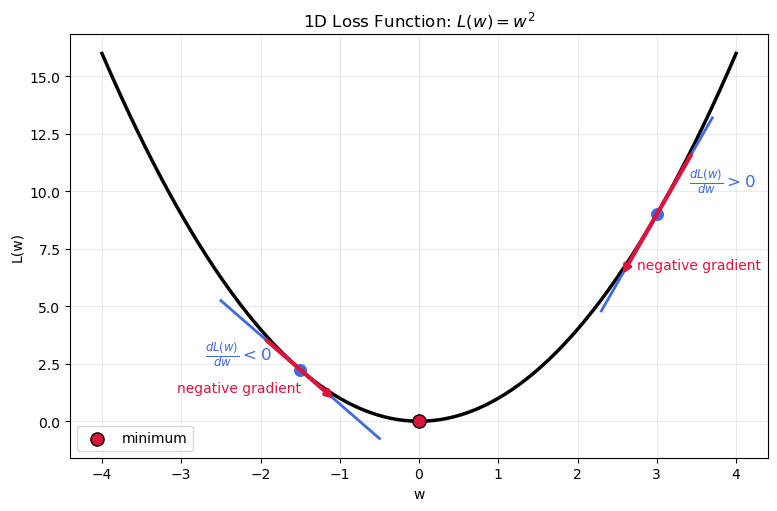

In [60]:
w_vals = np.linspace(-4, 4, 400)
f_vals = w_vals ** 2

left_w = -1.5
right_w = 3.0
left_f = left_w ** 2
right_f = right_w ** 2
left_slope = 2 * left_w
right_slope = 2 * right_w

left_tangent_w = np.linspace(left_w - 1.0, left_w + 1.0, 100)
left_tangent_f = left_f + left_slope * (left_tangent_w - left_w)
right_tangent_w = np.linspace(right_w - 0.7, right_w + 0.7, 100)
right_tangent_f = right_f + right_slope * (right_tangent_w - right_w)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(w_vals, f_vals, color="black", linewidth=2.5)
ax.scatter([left_w, right_w], [left_f, right_f], color="royalblue", s=70, zorder=3)
ax.scatter([0], [0], color="crimson", edgecolor="black", s=90, zorder=4, label="minimum")

ax.plot(left_tangent_w, left_tangent_f, color="royalblue", linewidth=2)
ax.plot(right_tangent_w, right_tangent_f, color="royalblue", linewidth=2)
ax.text(left_w - 1.2, left_f + 0.4, r"$\frac{dL(w)}{dw}<0$", color="royalblue", fontsize=12, fontweight="bold")
ax.text(right_w + 0.4, right_f + 1.2, r"$\frac{dL(w)}{dw}>0$", color="royalblue", fontsize=12, fontweight="bold")

ax.annotate(
    "",
    xy=(left_w + 0.45, left_f + left_slope * 0.45),
    xytext=(left_w - 0.45, left_f + left_slope * (-0.45)),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=3),
)
ax.annotate(
    "negative gradient",
    xy=(left_w + 0.25, left_f + left_slope * 0.45),
    xytext=(left_w - 1.55, left_f - 1.0),
    color="crimson",
)
ax.annotate(
    "",
    xy=(right_w - 0.45, right_f + right_slope * (-0.45)),
    xytext=(right_w + 0.45, right_f + right_slope * 0.45),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=3),
)
ax.annotate(
    "negative gradient",
    xy=(right_w - 0.45, right_f + right_slope * (-0.45)),
    xytext=(right_w - 0.25, right_f - 2.4),
    color="crimson",
)

ax.set_xlabel("w")
ax.set_ylabel("L(w)")
ax.set_title(r"1D Loss Function: $L(w)=w^2$")
ax.grid(alpha=0.25)
ax.legend()
fig.savefig(FIG_DIR / "00_1d_derivative_and_descent_direction.pdf", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
def loss_fn(w):
    """Compute the toy loss for a 2D parameter vector."""
    w1, w2 = w
    return (w1 - 2.0) ** 2 + 0.5 * (w2 + 1.0) ** 2


def grad_fn(w):
    """Compute the gradient of the toy loss."""
    w1, w2 = w
    d_w1 = 2.0 * (w1 - 2.0)
    d_w2 = w2 + 1.0
    return np.array([d_w1, d_w2])

Before we optimize, it helps to visualize the shape of the function.
The 3D surface plot below shows how the loss changes across the 2D parameter space, with the loss value on the z-axis.

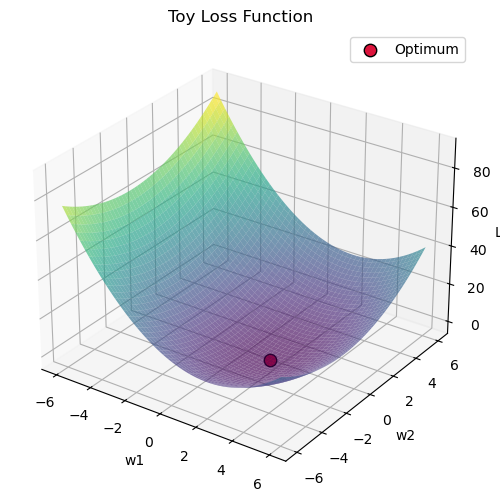

In [15]:
w1_vals = np.linspace(-6, 6, 200)
w2_vals = np.linspace(-6, 6, 200)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = (W1 - 2.0) ** 2 + 0.5 * (W2 + 1.0) ** 2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W1, W2, Z, cmap="viridis", edgecolor="none", alpha=0.65)
ax.scatter([2.0], [-1.0], [0.0], color="crimson", edgecolor="black", s=80, label="Optimum")
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Loss")
ax.set_title("Toy Loss Function")
ax.view_init(elev=28, azim=-55)
ax.legend()
fig.savefig(FIG_DIR / "01_toy_loss_function_3d.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 2. Strategy #1: Random Search

The idea of random search is:

1. Sample a random set of parameters
2. Compute the loss
3. Keep the best parameters seen so far

The problem with this method is that it has no idea which direction is better, so it relies entirely on luck.

In [16]:
start_w = np.array([-5.0, 4.0])


def random_search(start_w, num_trials=30, search_scale=6.0):
    best_w = start_w.astype(float).copy()
    best_loss = loss_fn(best_w)
    history = []

    history.append(
        {
            "step": 0,
            "candidate_w": best_w.copy(),
            "candidate_loss": best_loss,
            "best_w": best_w.copy(),
            "best_loss": best_loss,
        }
    )

    for step in range(1, num_trials):
        candidate_w = np.random.uniform(-search_scale, search_scale, size=2)
        candidate_loss = loss_fn(candidate_w)

        if candidate_loss < best_loss:
            best_loss = candidate_loss
            best_w = candidate_w.copy()

        history.append(
            {
                "step": step,
                "candidate_w": candidate_w.copy(),
                "candidate_loss": candidate_loss,
                "best_w": best_w.copy(),
                "best_loss": best_loss,
            }
        )

    return best_w, best_loss, history

In [17]:
best_w_random, best_loss_random, random_history = random_search(start_w)

print("Random search result")
print(f"start_w   = [{start_w[0]:.2f}, {start_w[1]:.2f}]")
print(f"best_w    = [{best_w_random[0]:.2f}, {best_w_random[1]:.2f}]")
print(f"best_loss = {best_loss_random:.4f}")

for record in random_history[:10]:
    print(
        f"step {record['step']:2d}: "
        f"candidate_w = [{record['candidate_w'][0]:.2f}, {record['candidate_w'][1]:.2f}], "
        f"candidate_loss = {record['candidate_loss']:.4f}, "
        f"best_loss = {record['best_loss']:.4f}"
    )

Random search result
start_w   = [-5.00, 4.00]
best_w    = [2.21, -0.72]
best_loss = 0.0841
step  0: candidate_w = [-5.00, 4.00], candidate_loss = 61.5000, best_loss = 61.5000
step  1: candidate_w = [-1.51, 5.41], candidate_loss = 32.8236, best_loss = 32.8236
step  2: candidate_w = [2.78, 1.18], candidate_loss = 2.9993, best_loss = 2.9993
step  3: candidate_w = [-4.13, -4.13], candidate_loss = 42.4420, best_loss = 2.9993
step  4: candidate_w = [-5.30, 4.39], candidate_loss = 67.8820, best_loss = 2.9993
step  5: candidate_w = [1.21, 2.50], candidate_loss = 6.7328, best_loss = 2.9993
step  6: candidate_w = [-5.75, 5.64], candidate_loss = 82.1464, best_loss = 2.9993
step  7: candidate_w = [3.99, -3.45], candidate_loss = 6.9633, best_loss = 2.9993
step  8: candidate_w = [-3.82, -3.80], candidate_loss = 37.7679, best_loss = 2.9993
step  9: candidate_w = [-2.35, 0.30], candidate_loss = 19.7558, best_loss = 2.9993


### Visualize the Random Search Decision Process in 3D

This plot shows the random-search decision process on the 3D loss surface:

- the z-axis is the loss value
- at each step, the arrow starts from the current best point
- green solid arrows mean the new trial is better, so the best point is updated
- gray dashed arrows mean the new trial is worse, so it is rejected
- each rejected trial is marked with an `X` halfway along the dashed arrow

For example, if step 2 to step 4 all have larger loss than step 1, the visualization should show that the algorithm keeps using the `W` from step 1.

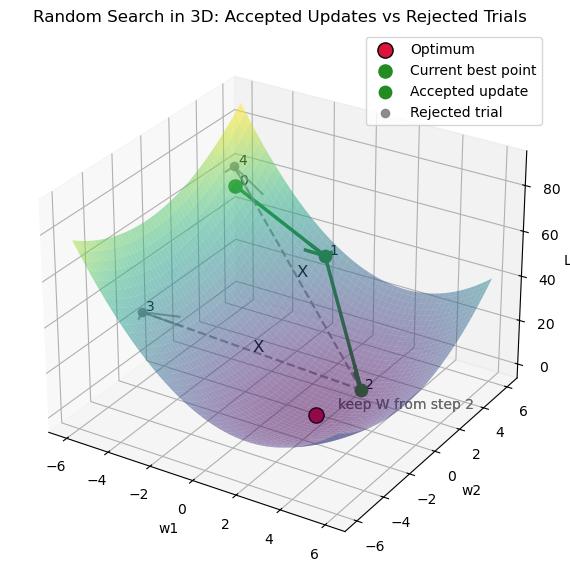

In [18]:
num_visualized_steps = 5
visual_history = random_history[:num_visualized_steps]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W1, W2, Z, cmap="viridis", edgecolor="none", alpha=0.5)
ax.scatter([2.0], [-1.0], [0.0], color="crimson", edgecolor="black", s=120, label="Optimum")

accepted_label_used = False
rejected_label_used = False
best_stays_label_used = False

current_best_record = visual_history[0]
current_best_point = current_best_record["candidate_w"]
current_best_loss = current_best_record["candidate_loss"]

ax.scatter(
    [current_best_point[0]],
    [current_best_point[1]],
    [current_best_loss],
    color="forestgreen",
    s=90,
    label="Current best point",
)
ax.text(current_best_point[0] + 0.12, current_best_point[1] + 0.12, current_best_loss + 0.4, "0")

for record in visual_history[1:]:
    candidate_point = record["candidate_w"]
    candidate_loss = record["candidate_loss"]
    is_improvement = candidate_loss < current_best_loss

    if is_improvement:
        ax.plot(
            [current_best_point[0], candidate_point[0]],
            [current_best_point[1], candidate_point[1]],
            [current_best_loss, candidate_loss],
            color="forestgreen",
            linewidth=2.5,
        )
        arrow_start = current_best_point + 0.82 * (candidate_point - current_best_point)
        arrow_start_loss = current_best_loss + 0.82 * (candidate_loss - current_best_loss)
        ax.quiver(
            arrow_start[0],
            arrow_start[1],
            arrow_start_loss,
            candidate_point[0] - arrow_start[0],
            candidate_point[1] - arrow_start[1],
            candidate_loss - arrow_start_loss,
            arrow_length_ratio=0.45,
            color="forestgreen",
            linewidth=2.5,
        )
        ax.scatter(
            [candidate_point[0]],
            [candidate_point[1]],
            [candidate_loss],
            color="forestgreen",
            s=80,
            label=None if accepted_label_used else "Accepted update",
        )
        accepted_label_used = True
        ax.text(candidate_point[0] + 0.12, candidate_point[1] + 0.12, candidate_loss + 0.4, f"{record['step']}")
        current_best_point = candidate_point.copy()
        current_best_loss = candidate_loss
    else:
        ax.plot(
            [current_best_point[0], candidate_point[0]],
            [current_best_point[1], candidate_point[1]],
            [current_best_loss, candidate_loss],
            color="gray",
            linestyle="dashed",
            linewidth=1.6,
            alpha=0.8,
        )
        rejected_arrow_start = current_best_point + 0.82 * (candidate_point - current_best_point)
        rejected_arrow_start_loss = current_best_loss + 0.82 * (candidate_loss - current_best_loss)
        ax.quiver(
            rejected_arrow_start[0],
            rejected_arrow_start[1],
            rejected_arrow_start_loss,
            candidate_point[0] - rejected_arrow_start[0],
            candidate_point[1] - rejected_arrow_start[1],
            candidate_loss - rejected_arrow_start_loss,
            arrow_length_ratio=0.45,
            color="gray",
            linewidth=1.4,
            alpha=0.8,
        )
        ax.scatter(
            [candidate_point[0]],
            [candidate_point[1]],
            [candidate_loss],
            color="gray",
            s=35,
            alpha=0.9,
            label=None if rejected_label_used else "Rejected trial",
        )
        rejected_label_used = True
        ax.text(candidate_point[0] + 0.12, candidate_point[1] + 0.12, candidate_loss + 0.4, f"{record['step']}")
        mid_x = 0.5 * (current_best_point[0] + candidate_point[0])
        mid_y = 0.5 * (current_best_point[1] + candidate_point[1])
        mid_z = 0.5 * (current_best_loss + candidate_loss)
        ax.text(mid_x, mid_y, mid_z, "X", color="black", fontsize=12)
        ax.text(
            current_best_point[0] + 0.05,
            current_best_point[1] - 1.9,
            current_best_loss + 0.9,
            f"keep W from step {current_best_record['step']}",
            color="dimgray",
            fontsize=10,
        )

    if is_improvement:
        current_best_record = record

ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Loss")
ax.set_title("Random Search in 3D: Accepted Updates vs Rejected Trials")
ax.view_init(elev=28, azim=-58)
ax.legend()
fig.savefig(FIG_DIR / "02_random_search_process_3d.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 3. Strategy #2: Gradient Descent

The key idea of gradient descent is:

- the gradient tells us the direction of fastest increase in loss
- so if we move in the negative gradient direction, the loss decreases

Update rule:

$$
w \leftarrow w - \eta \nabla L(w)
$$

Here, $\eta$ is the learning rate.

In [19]:
def gradient_descent(start_w, learning_rate=0.2, num_steps=25):
    w = start_w.astype(float).copy()
    history = []

    for step in range(num_steps):
        loss = loss_fn(w)
        grad = grad_fn(w)
        history.append(
            {
                "step": step,
                "w": w.copy(),
                "loss": loss,
                "grad": grad.copy(),
            }
        )
        w = w - learning_rate * grad

    final_loss = loss_fn(w)
    return w, final_loss, history

In [64]:
best_w_gd, best_loss_gd, gd_history = gradient_descent(start_w)

print("Gradient descent result")
print(f"start_w   = {start_w}")
print(f"best_w    = {best_w_gd}")
print(f"best_loss = {best_loss_gd:.6f}")

for record in gd_history[:10]:
    print(
        f"step {record['step']:2d}: "
        f"w = [{record['w'][0]:.2f}, {record['w'][1]:.2f}], "
        f"loss = {record['loss']:.4f}, "
        f"grad = [{record['grad'][0]:.2f}, {record['grad'][1]:.2f}]"
    )

Gradient descent result
start_w   = [-5.  4.]
best_w    = [ 1.9999801  -0.98111053]
best_loss = 0.000178
step  0: w = [-5.00, 4.00], loss = 61.5000, grad = [-14.00, 5.00]
step  1: w = [-2.20, 3.00], loss = 25.6400, grad = [-8.40, 4.00]
step  2: w = [-0.52, 2.20], loss = 11.4704, grad = [-5.04, 3.20]
step  3: w = [0.49, 1.56], loss = 5.5629, grad = [-3.02, 2.56]
step  4: w = [1.09, 1.05], loss = 2.9202, grad = [-1.81, 2.05]
step  5: w = [1.46, 0.64], loss = 1.6385, grad = [-1.09, 1.64]
step  6: w = [1.67, 0.31], loss = 0.9657, grad = [-0.65, 1.31]
step  7: w = [1.80, 0.05], loss = 0.5882, grad = [-0.39, 1.05]
step  8: w = [1.88, -0.16], loss = 0.3657, grad = [-0.24, 0.84]
step  9: w = [1.93, -0.33], loss = 0.2302, grad = [-0.14, 0.67]


### Visualize Gradient Descent Only

This plot shows only the gradient descent trajectory on the 3D loss surface:

- the z-axis is the loss value
- the red path shows how the parameters move step by step
- the path smoothly descends toward the optimum


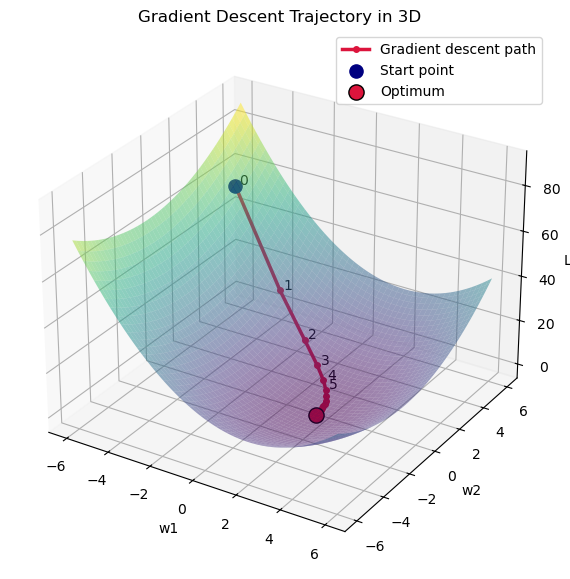

In [21]:
gd_points = np.array([record["w"] for record in gd_history])
gd_losses = np.array([record["loss"] for record in gd_history])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W1, W2, Z, cmap="viridis", edgecolor="none", alpha=0.5)
ax.plot(
    gd_points[:, 0],
    gd_points[:, 1],
    gd_losses,
    "o-",
    color="crimson",
    linewidth=2.5,
    markersize=4,
    label="Gradient descent path",
)
ax.scatter(
    [gd_points[0, 0]],
    [gd_points[0, 1]],
    [gd_losses[0]],
    color="navy",
    s=90,
    label="Start point",
)
ax.scatter([2.0], [-1.0], [0.0], color="crimson", edgecolor="black", s=120, label="Optimum")

for step, point, loss in zip(range(min(6, len(gd_points))), gd_points[:6], gd_losses[:6]):
    ax.text(point[0] + 0.1, point[1] + 0.1, loss + 0.3, f"{step}")

ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Loss")
ax.set_title("Gradient Descent Trajectory in 3D")
ax.view_init(elev=28, azim=-58)
ax.legend()
fig.savefig(FIG_DIR / "03_gradient_descent_trajectory_3d.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 4. Compare How the Loss Decreases

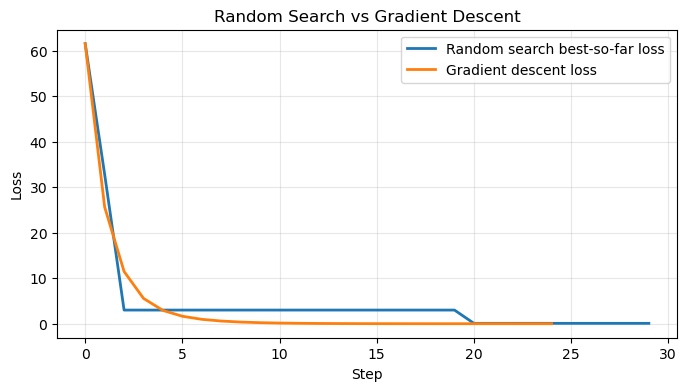

In [22]:
random_best_losses = [record["best_loss"] for record in random_history]
gd_losses = [record["loss"] for record in gd_history]

plt.figure(figsize=(8, 4))
plt.plot(random_best_losses, label="Random search best-so-far loss", linewidth=2)
plt.plot(gd_losses, label="Gradient descent loss", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Random Search vs Gradient Descent")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / "04_random_search_vs_gradient_descent_loss.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 5. Key Takeaways for the Slides

1. Random search does not use any local structure of the function; it is just guessing.
2. Gradient descent uses the directional information provided by the gradient, so it is usually much more efficient.
3. If the learning rate is too small, convergence is slow; if it is too large, the optimization may oscillate or diverge.
4. In real deep learning, the parameter space is much higher-dimensional than 2D, but the core idea is the same.